In [65]:
from sodetlib.det_config import DetConfig
import sodetlib.smurf_funcs.smurf_ops as so
import sodetlib.smurf_funcs.optimize_params as op
import sodetlib.util as su
from importlib import reload
from tqdm import tqdm
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from scipy.signal import welch


# Warnings are annoying
import warnings
warnings.filterwarnings("ignore")

# DetConfig setup

These lines will load the sys-config, pysmurf-config, and device config files, and use them to generate a pysmurf instance for slot number 2.

Because we are just setting up the pysmurf instance, we do not need to apply parameters from the device config. We are also starting pysmurf with `make_logfile=True`, which tells it to write to a log file instead of stdout. The log file its written to is printed below, and you can monitor it in real time by running `tail -f <log_file>` from the cmd line.

In [6]:
cfg = DetConfig()
cfg.load_config_files(slot=2)
S = cfg.get_smurf_control(apply_dev_configs=False, make_logfile=True)

In [7]:
print(f"Logs sent to: {S.log_file}")

Logs sent to: /data/smurf_data/20210714/1626233656/outputs/1626233656.log


In [11]:
bands = np.arange(8)

## Amplifier Check
The cryo_amp_check will tell you whether or not your amplifiers are correctly biased, and check the jesd connections. 

(On the SAT, the amplifier voltage output is half what we command, so it complains tha we are not in range, but the final current and voltage values are still what we expect)

In [76]:
so.cryo_amp_check(S, cfg)


Checking biases

Scanning hemt bias voltage
Vg adjustment would go out of range (-1.2, -0.6). Unable to change hemt_Id to desired value

Scanning 50K bias voltage
Final hemt current = 10.5058593875
Desired hemt current = 10.467187512499999
hemt current within range of desired value:  False
Final hemt gate voltage is -1.9999987199999998
Final 50K current = 13.792968749999998
Desired 50K current = 13.6640625
50K current within range of desired value:True
Final 50K gate voltage is -0.649997

Checking JESD Connections
bay 0 jesd_tx connection working
bay 0 jesd_rx connection working
bay 1 jesd_tx connection working
bay 1 jesd_rx connection working

Checking full-band response for band 0
Full band response check passed

Health check finished! Final status
True - Hemt biased: 	True
 - Hemt Id in range: 	False
 - Hemt (Id, Vg): 	(10.5058593875, -1.9999987199999998)

True - 50K biased: 		True
 - 50K Id in range: 	True
 - 50K (Id, Vg): 	(13.792968749999998, -0.649997)

 - Response check: 	True

False

# Estimating Phase Delay

The phase delay must be measured before starting tuning

  0%|          | 0/8 [00:00<?, ?it/s]

-------------------------------------------------------
Estimated cable_delay_us=0.7156652147219464
Estimated dsp_delay_us=8.886862900692918
Estimated processing_delay_us=8.171197685970972
-------------------------------------------------------


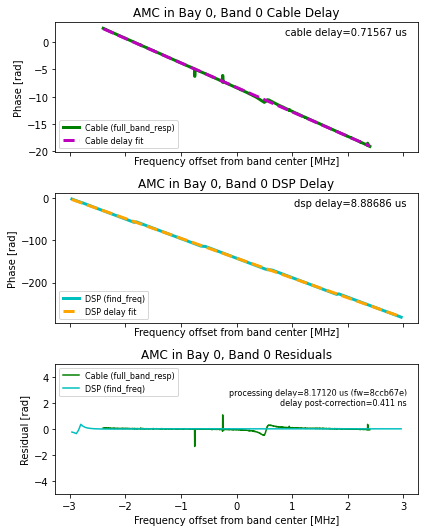

 12%|█▎        | 1/8 [00:16<01:52, 16.01s/it]

-------------------------------------------------------
Estimated cable_delay_us=0.7116467930541898
Estimated dsp_delay_us=8.870507084623169
Estimated processing_delay_us=8.15886029156898
-------------------------------------------------------


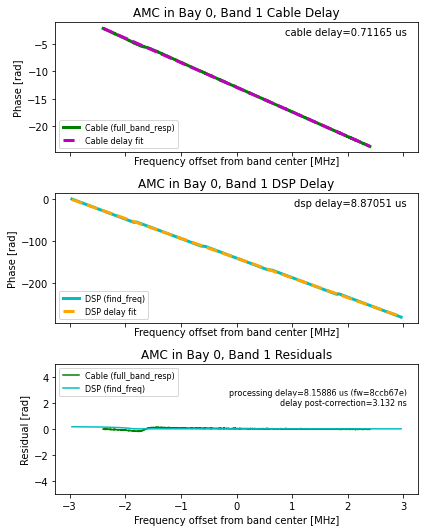

 25%|██▌       | 2/8 [00:32<01:37, 16.22s/it]

-------------------------------------------------------
Estimated cable_delay_us=0.7130589921968112
Estimated dsp_delay_us=8.88435474546063
Estimated processing_delay_us=8.171295753263818
-------------------------------------------------------


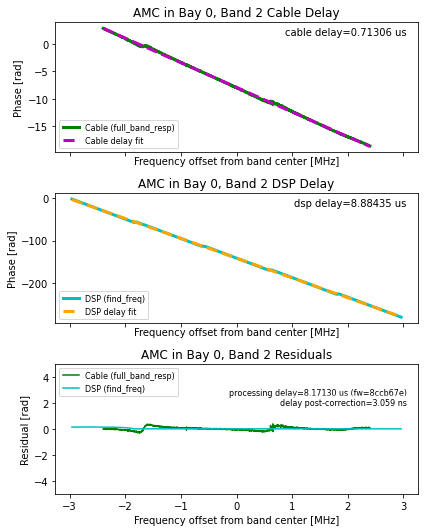

 38%|███▊      | 3/8 [00:49<01:23, 16.70s/it]

-------------------------------------------------------
Estimated cable_delay_us=0.7169192456978057
Estimated dsp_delay_us=8.86341270440327
Estimated processing_delay_us=8.146493458705464
-------------------------------------------------------


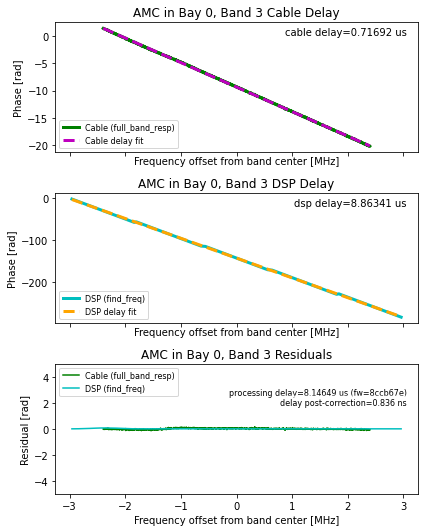

 50%|█████     | 4/8 [01:06<01:07, 16.81s/it]

-------------------------------------------------------
Estimated cable_delay_us=0.7218126887646259
Estimated dsp_delay_us=8.860557586310033
Estimated processing_delay_us=8.138744897545408
-------------------------------------------------------


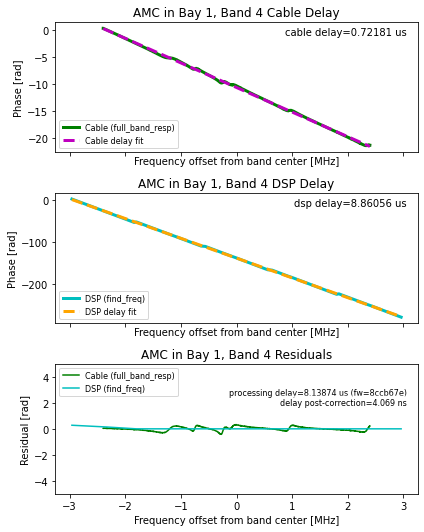

 62%|██████▎   | 5/8 [01:25<00:52, 17.51s/it]

-------------------------------------------------------
Estimated cable_delay_us=0.7290186400779045
Estimated dsp_delay_us=8.888550926403335
Estimated processing_delay_us=8.15953228632543
-------------------------------------------------------


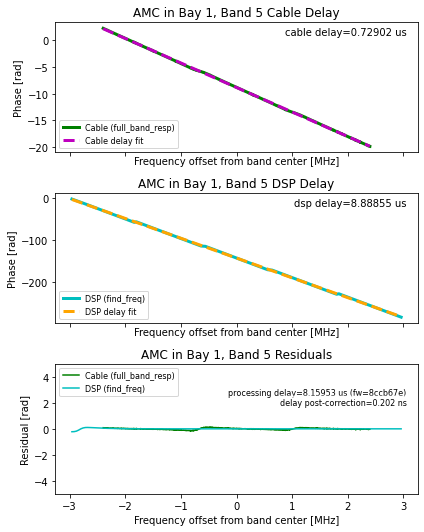

 75%|███████▌  | 6/8 [01:44<00:36, 18.09s/it]

-------------------------------------------------------
Estimated cable_delay_us=0.726046408507105
Estimated dsp_delay_us=8.886681162018835
Estimated processing_delay_us=8.16063475351173
-------------------------------------------------------


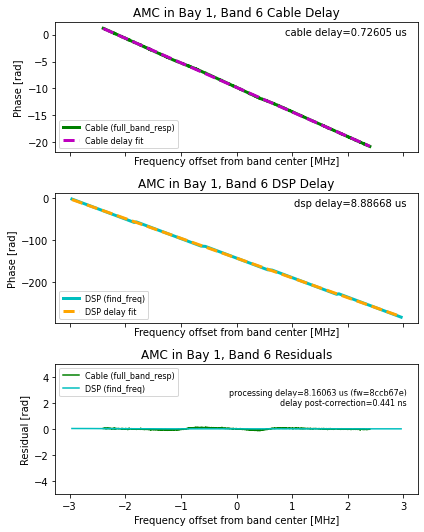

 88%|████████▊ | 7/8 [02:05<00:18, 18.89s/it]

-------------------------------------------------------
Estimated cable_delay_us=0.7285672796155624
Estimated dsp_delay_us=8.880501784758035
Estimated processing_delay_us=8.151934505142473
-------------------------------------------------------


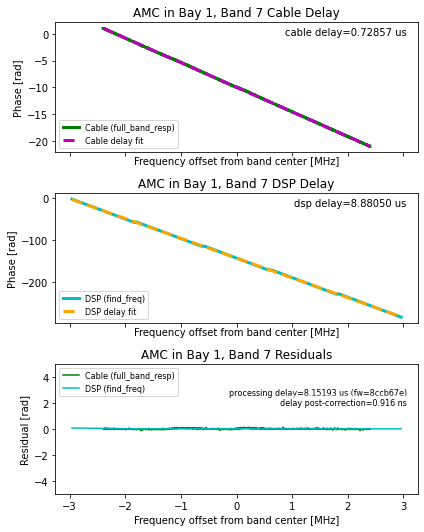

100%|██████████| 8/8 [02:26<00:00, 18.33s/it]


In [15]:
for band in tqdm(bands):
    S.estimate_phase_delay(band)

# Initial setup

The initial tune can be done with the `find_and_tune_freq` function the the `smurf_ops` module, which will run `find_freq` and `setup_notches` for each band. If you run with `dump_cfg=True`, the tunefile will automatically be written to the cfg object and dumped to the device cfg file (this is the defualt).

Total time: ~20 min

Tuning band 0...


/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:903: RuntimeWarning: invalid value encountered in double_scalars
  if 1-amp[idx]/med_amp[idx] > amp_cut:


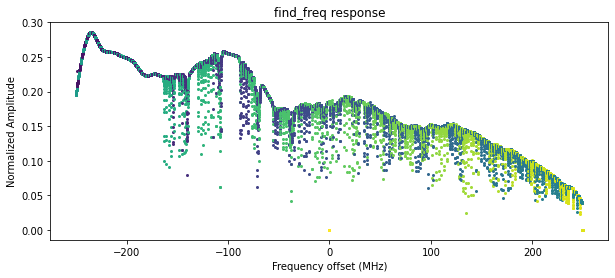

Tuning band 1...


/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:903: RuntimeWarning: invalid value encountered in double_scalars
  if 1-amp[idx]/med_amp[idx] > amp_cut:


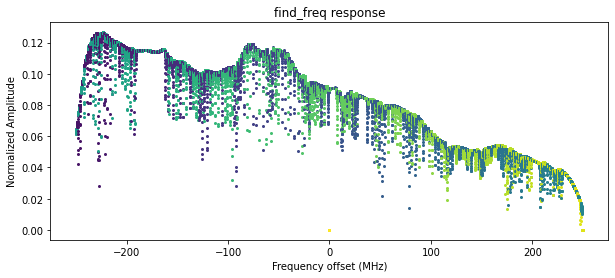

Tuning band 2...


/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:903: RuntimeWarning: invalid value encountered in double_scalars
  if 1-amp[idx]/med_amp[idx] > amp_cut:


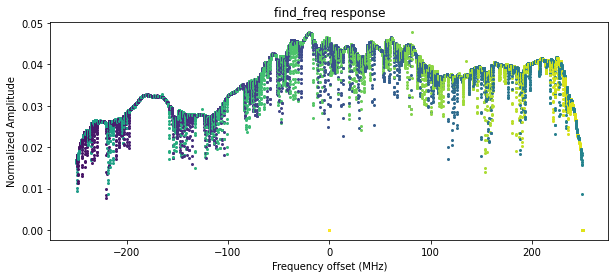

Tuning band 3...


/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:903: RuntimeWarning: invalid value encountered in double_scalars
  if 1-amp[idx]/med_amp[idx] > amp_cut:


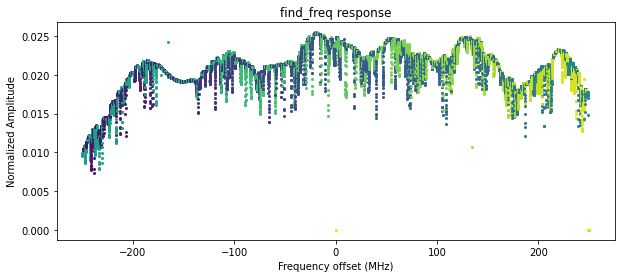

Tuning band 4...


/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:903: RuntimeWarning: invalid value encountered in double_scalars
  if 1-amp[idx]/med_amp[idx] > amp_cut:


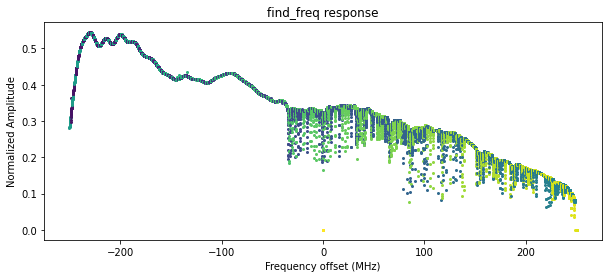

Tuning band 5...


/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:903: RuntimeWarning: invalid value encountered in double_scalars
  if 1-amp[idx]/med_amp[idx] > amp_cut:


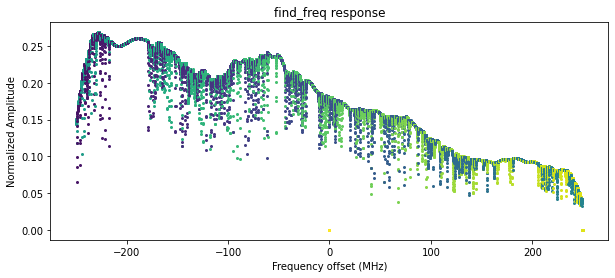

Tuning band 6...


/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:903: RuntimeWarning: invalid value encountered in double_scalars
  if 1-amp[idx]/med_amp[idx] > amp_cut:


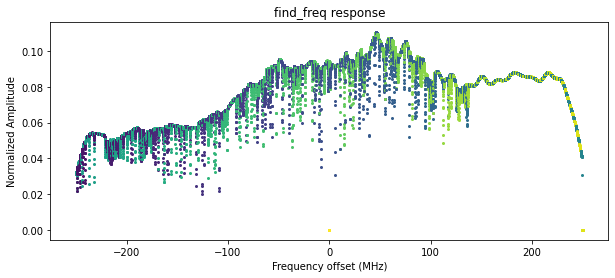

Tuning band 7...


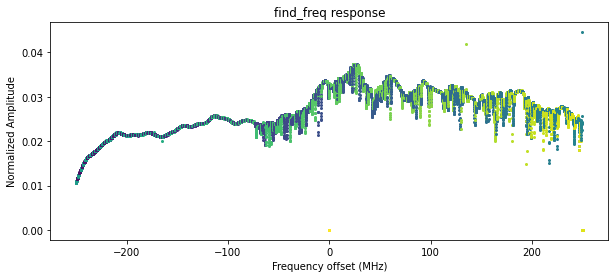

Total num resonators on: 1285
Tune file: /data/smurf_data/tune/1626235053_tune.npy
Updating config tunefile...


(1285, '/data/smurf_data/tune/1626235053_tune.npy')

In [13]:
so.find_and_tune_freq(S, cfg, bands, dump_cfg=True)

In [21]:
S.load_tune('/data/smurf_data/tune/1626235053_tune.npy')
for band in bands:
    S.relock(band)
    S.run_serial_gradient_descent(band)
    S.run_serial_eta_scan(band)

## Optimize Tracking
The optimize_tracking function will determine the optimal frac_pp for each band to attain exactly a certain number of phi0. 

In [25]:
reload(so)
reload(op)

<module 'sodetlib.smurf_funcs.optimize_params' from '/sodetlib/sodetlib/smurf_funcs/optimize_params.py'>

In [26]:
for band in bands:
    op.optimize_tracking(S, cfg, band, show_plot=True, update_cfg=True)

Optimizing tracking setup for band 0
170/168 channels have r-squared > 0.95
This is more than 50%, shutting off bad channels.


/sodetlib/sodetlib/smurf_funcs/smurf_ops.py:343: RuntimeWarning: divide by zero encountered in true_divide
  r = 1 - ssres/sstot


1/171 Channels not tracking on band 0
Optimized frac_pp: 0.1522857926795654 for lms_freq = 20000.0
Optimizing tracking setup for band 1
177/180 channels have r-squared > 0.95
This is more than 50%, shutting off bad channels.
1/180 Channels not tracking on band 1
Optimized frac_pp: 0.1532699682578066 for lms_freq = 20000.0
Optimizing tracking setup for band 2
184/185 channels have r-squared > 0.95
This is more than 50%, shutting off bad channels.
5/185 Channels not tracking on band 2
Optimized frac_pp: 0.15272088008168921 for lms_freq = 20000.0
Optimizing tracking setup for band 3
174/175 channels have r-squared > 0.95
This is more than 50%, shutting off bad channels.
14/175 Channels not tracking on band 3
Optimized frac_pp: 0.15244453986317136 for lms_freq = 20000.0
Optimizing tracking setup for band 4
125/127 channels have r-squared > 0.95
This is more than 50%, shutting off bad channels.
2/127 Channels not tracking on band 4
Optimized frac_pp: 0.16634408235556447 for lms_freq = 20000

These optimized config values have already been dumped to the cfg file:

In [28]:
!cat /config/device_configs/s2_ufm.yaml

experiment:
  amp_50k_Id: 13.6640625
  amp_50k_Vg: -0.649997
  amp_hemt_Id: 10.467187512499999
  amp_hemt_Vg: -1.9999987199999998
  bias_line_resistance: 10076.0
  high_low_current_ratio: 2.03
  pA_per_phi0: 9000000.0
  tunefile: /data/smurf_data/tune/1626235053_tune.npy
bias_groups: {}
bands:
  AMC[0]:
    dc_att: [30, 30, 30, 30]
    drive: [12, 12, 12, 12]
    feedback_end_frac: [0.94, 0.94, 0.94, 0.94]
    feedback_start_frac: [0.019999999999999997, 0.019999999999999997, 0.019999999999999997,
      0.019999999999999997]
    flux_ramp_rate_khz: [4, 4.0, 4.0, 4.0]
    frac_pp: [0.1522857926795654, 0.1532699682578066, 0.15272088008168921, 0.15244453986317136]
    lms_freq_hz: [20000.0, 20000.0, 20000.0, 20000.0]
    lms_gain: [0, 0, 0, 0]
    nphi0: [5.0, 5.0, 5.0, 5.0]
    uc_att: [10, 14, 18, 20]
  AMC[1]:
    dc_att: [30, 30, 30, 30]
    drive: [12, 12, 12, 12]
    feedback_end_frac: [0.94, 0.94, 0.94, 0.94]
    feedback_start_frac: [0.019999999999999997, 0.019999999999999997, 0.01

By running tracking quality, we can see how many channels are tracking well, and disable the ones that aren't. To disable many channels at once, we set the amplitude scale array manually. This should be turned into an sodetlib or pysmurf function

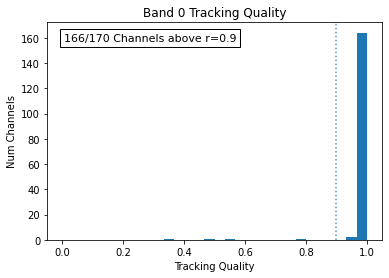

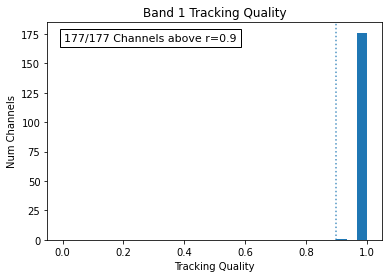

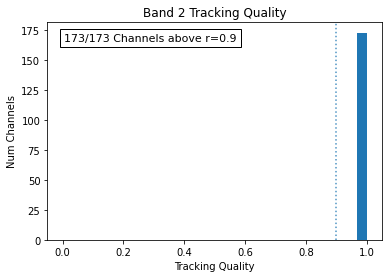

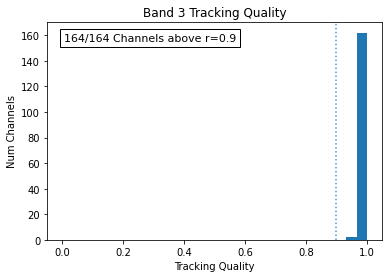

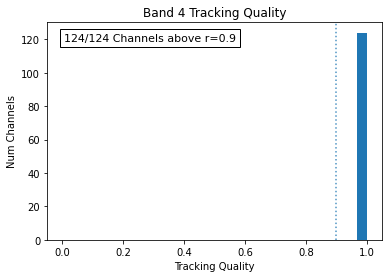

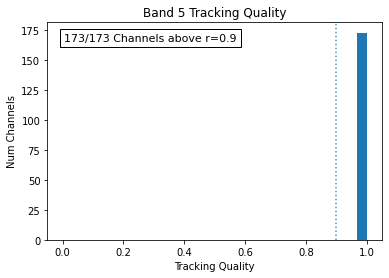

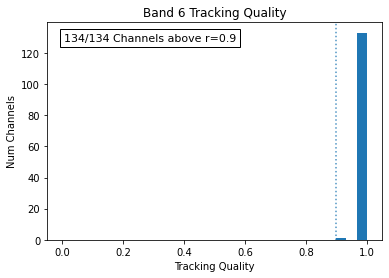

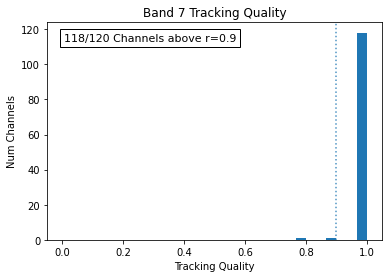

In [58]:
for band in bands:
    r2s, _, _, _ = so.tracking_quality(S, cfg, band, show_plots=True)
    asa = S.get_amplitude_scale_array(band)
    asa[r2s < 0.95] = 0
    S.set_amplitude_scale_array(band, asa)

## Taking noise data

To take noise data, we will stream data for 30 seconds, and then calculate the white noise and band medians.

Using the take_g3_data function, you can set tags that will make its way to the final G3 Files.

The function will return a "session_id", which can be used to easily read back data that's been streamed with G3. The session_id is just the timestamp that the streaming started

In [59]:
sid = so.take_g3_data(S, 30, make_freq_mask=False, tag='noise')
print(sid)

1626237370


Using the load_session function, we can read back streamed data into an axis manager. This function also takes the cfg object, so it knows which stream-id to read from.

In [60]:
am = so.load_session(cfg, sid)

100%|██████████| 1/1 [00:00<00:00,  6.71it/s]


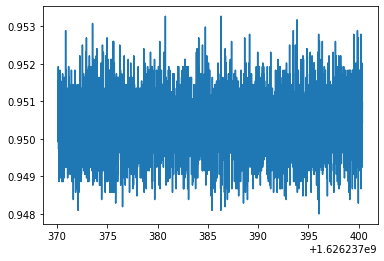

In [64]:
plt.plot(am.timestamps[10:], am.signal[2][10:])

Plot white noise levels of each band to make sure that they match expectations 

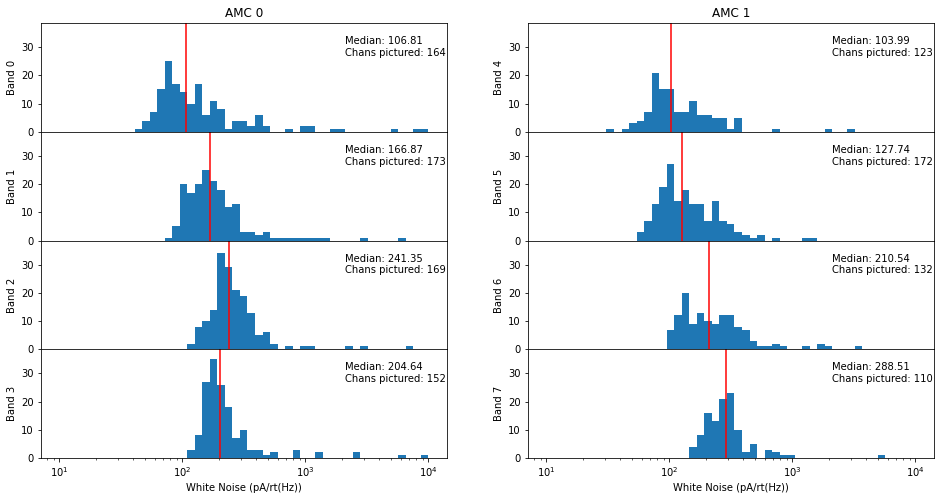

In [75]:
fig, axes = so.plot_band_noise(am, nbins=50)